In [1]:
from database import Database

dict_db_path = r"D:\git-projects\vis-context-agent\song-bureaucracy\data\database\song_bureaucracy_dictionary.db"
entry_db_path = r"D:\git-projects\vis-context-agent\song-bureaucracy\data\database\song_bureaucracy_entries.db"

dict_table = "chapter8t10"
entry_table = "entries0130"

database = Database(dict_db_path, dict_table, entry_db_path, entry_table)
database.refresh_entry_table()

print(len(database.indexes))

成功插入 833 条记录到 entries0130 表
833


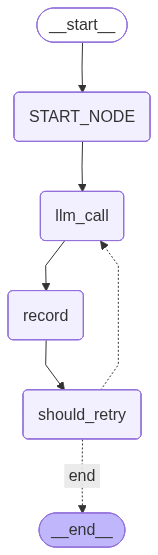

In [2]:
import os
os.environ["IFLOW_API_KEY"] = "sk-84596fd20d0b693b722273d0d2328a94"

import sys
sys.path.append(r"D:\git-projects\vis-context-agent\agents")

from graph_agent.llms.llm import LLMTool
from graph_agent.llms.apis.iflow import IFlowApi

llm = IFlowApi(model="qwen3-max", max_tokens=16384)
llm_tool = LLMTool("qwen3-max", llm)
llm_tool.compile()

In [12]:
"""构建输入条目列表（每次提供的所有条目文本不超过 2000 字）"""
import json
with open(r"D:\git-projects\vis-context-agent\song-bureaucracy\data\refined_tables\第八至十编-官制索引.json", "r", encoding="utf-8") as f:
  entry_indexes = json.load(f)

entry_indexes_texts = [f"{x[0]}-{x[1]}" for x in entry_indexes]

all_input_entries = []
for entry in entry_indexes:
  title, page = entry
  entry_info = database.get_dict_entry(title, page)
  entry_text = Database.dict_entry_to_str(entry_info)
  all_input_entries.append(entry_text)

print(len(all_input_entries))

input_entries_list = []
index = 0
current_entries = []
current_length = 0
while index < len(all_input_entries):
  if current_length == 0 or current_length + len(all_input_entries[index]) <= 2000:
    current_entries.append(all_input_entries[index])
    current_length += len(all_input_entries[index])
    index += 1
  else:
    input_entries_list.append(current_entries)
    current_entries = []
    current_length = 0

if current_length > 0:
  input_entries_list.append(current_entries)

print(len(input_entries_list))
print('\n'.join(input_entries_list[0]))


833
166
河北兵马大元帅府
文本来源：宋代官制辞典/I.职官条目分类目录/第八编 军事统率机构与地方治安机构类/一、大元帅府、都督府门 482页
基本介绍：官司名。北宋靖康元年闰十一月，宋钦宗传檄，授命康王为河北兵马大元帅。十二月一日，赵构开大元帅府，以募兵勤王抗金，解救京师之围为名（《要录》卷1）。南宋建炎元年五月十日大元帅府解散（《宋会要·职官》37之2《元帅府》）。
简称: ①大元帅府、元帅府。《宋会要·职官》37之1：“高宗建炎元年五月二日，诏大元帅府限十日结局。”《要录》卷1靖康元年十一月己酉：“拜王（康王赵构)河北兵马大元帅。”十二月壬戌朔：“王开元帅府。”②帅府。《要录》卷1乙亥：“乃遣人伴送至帅府。”③霸府。《要录》卷1，靖康元年闰十一月己酉：“拜王河北兵马大元帅。”原注引《汪伯彦日历》：“然霸府肇启开，事出仓卒。盖靖康元年闰十一月，檄到日，康王可充兵马大元帅。”④天下兵马大元帅府。过称。《金佗粹编》卷4《行实编年》：“（靖康元年）冬，高宗皇帝以天下兵马大元帅开府河朔。”《要录》卷4，建炎元年四月癸亥：“（赵子崧）望大王遵故事，以天下兵马大元帅承制号召四方。”

河北兵马大元帅
文本来源：宋代官制辞典/I.职官条目分类目录/第八编 军事统率机构与地方治安机构类/一、大元帅府、都督府门 482页
基本介绍：军职名。北宋靖康元年闰十一月，命置。南宋建炎元年五月十日罢。由亲王担任，统率元帅府勤王兵、募兵五军万人之众（《要录》卷1）。
简称与别名: ①兵马大元帅。《要录》卷1丁酉：“拜王河北兵马大元帅。”注引《赵牲之遗史》：“康王可充兵马大元帅府。”②大元帅。《要录》卷1乙卯：“济州始存大元帅驻泊之地。”同前书卷癸未：“仰大元帅康王将天下兵，分屯近甸。”

河北兵马元帅
文本来源：宋代官制辞典/I.职官条目分类目录/第八编 军事统率机构与地方治安机构类/一、大元帅府、都督府门 482页
基本介绍：军职名。靖康间康王赵构所开河北兵马大元帅府，设大元帅、元帅、副元帅（《宋史·高宗纪》1）。
简称: ①元帅。《宋史·奸臣·汪伯彦》：“王奉蜡书，开天下兵马大元帅府，以伯彦为副将。升元帅。”《宋史·高宗纪》1：“钦宗遣阎门祗候秦仔持蜡诏至相（州），拜帝为河北兵马大元帅，知中山府陈亨伯为元帅。”②兵马元帅。《要录》卷4丁亥：“兵马元帅汪伯彦。”

河北兵马副元帅


In [13]:
%reload_ext autoreload
%autoreload 2

import json
import re
from typing import List
from prompt_s1 import build_prompt_s1
from agent_funcs import call_tools, cot_to_str, tool_results_to_log_str, CoT

def load_json_string(input: str):
  pattern = r'```json\s*\n(.*?)\n\s*```'
  matches = re.findall(pattern, input, re.DOTALL)
  json_str = ""
  if len(matches) >= 1:
    json_str = matches[0]
  else:
    json_str = input

  return json.loads(json_str)

def run_cot(llm_tool, database, input_entries, entry_indexes, max_iterations=10):
  """
  运行 CoT（Chain of Thought）处理流程
  
  Args:
    llm_tool: LLM 工具实例，需要支持 invoke 方法
    database: Database 实例，用于工具调用
    input_entries: 输入的《辞典》条目列表（字符串列表）
    entry_indexes: 条目索引列表（"名称-页码"格式的字符串列表）
    max_iterations: 最大迭代次数，默认 10
  
  Returns:
    dict: 包含以下字段
      - CoT: 完整的思维链列表
      - finished: 是否完成
      - llm_call_count: LLM 调用次数
  """
  CoT_list: List[CoT] = []
  finished = False
  llm_call_count = 0
  
  while not finished and llm_call_count < max_iterations:
    llm_call_count += 1
    
    # 构建提示词
    cot_str = cot_to_str(CoT_list) if CoT_list else ""
    prompt = build_prompt_s1(input_entries, entry_indexes, cot_str)
    
    # 调用 LLM
    try:
      response = llm_tool.invoke({"prompt": prompt})
      content_text = response["response"]["response"]["choices"][0]["message"]["content"]
      
      # 解析 JSON 响应
      try:
        content = load_json_string(content_text)
      except Exception as e:
        print(f"解析 JSON 失败：{e}")
        print(f"响应内容：{content_text[:500]}...")
        CoT_list.append({
          "role": "system",
          "type": "error",
          "content": f"解析 JSON 失败：{str(e)}"
        })
        continue
      
      # 处理 Thought
      if "thought" in content:
        CoT_list.append({
          "role": "assistant",
          "type": "thought",
          "content": content["thought"]
        })
        print("=" * 25, "Thought", "=" * 25)
        print(content["thought"])
      
      # 处理 Action
      if "action" in content:
        if content["action"] == "Tasks All Finished":
          CoT_list.append({
            "role": "assistant",
            "type": "action",
            "content": content["action"]
          })
          print("=" * 25, "Tasks All Finished", "=" * 25)
          finished = True
        elif isinstance(content["action"], list):
          # Action 是工具调用列表
          tool_returns = call_tools(database, content["action"])
          tool_results_str = tool_results_to_log_str(tool_returns)
          
          CoT_list.append({
            "role": "assistant",
            "type": "action",
            "content": json.dumps(content["action"], ensure_ascii=False, indent=2)
          })
          CoT_list.append({
            "role": "system",
            "type": "observation",
            "content": tool_results_str
          })
          
          print("=" * 25, "Tool Call", "=" * 25)
          for ret in tool_returns:
            parameter_texts = []
            for key, value in ret["parameters"].items():
              parameter_texts.append(f"{key}={value}")
            print("=" * 20)
            print(ret["action_description"])
            print(f"调用工具：{ret['tool_name']}({', '.join(parameter_texts)})")
            if ret["error"] is not None:
              print(f"失败：{ret['error']}")
            else:
              print("调用成功")
            if "reasoning" in ret and ret["reasoning"] is not None:
              print("引用依赖：", json.dumps(ret["reasoning"], ensure_ascii=False, indent=2))

        else:
          # Action 是字符串（非工具调用）
          CoT_list.append({
            "role": "assistant",
            "type": "action",
            "content": content["action"]
          })
          print("=" * 25, "Action", "=" * 25)
          print(content["action"])
          
          # 处理 Observation
          if "observation" in content and content["observation"] != "":
            CoT_list.append({
              "role": "assistant",
              "type": "observation",
              "content": content["observation"]
            })
            print("=" * 25, "Observation (Assistant)", "=" * 25)
            print(content["observation"])
          else:
            CoT_list.append({
              "role": "system",
              "type": "observation",
              "content": "非工具调用的 action，应当由 assistant 自行生成 observation 结果"
            })
            print("=" * 25, "Observation (System)", "=" * 25)
            print("非工具调用的 action，应当由 assistant 自行生成 observation 结果")
      
    except Exception as e:
      print(f"LLM 调用异常：{e}")
      CoT_list.append({
        "role": "system",
        "type": "error",
        "content": f"LLM 调用异常：{str(e)}"
      })
      # 可以选择继续或中断
      # break
  
  return {
    "CoT": CoT_list,
    "finished": finished,
    "llm_call_count": llm_call_count
  }


In [ ]:
import time
import uuid

cot_save_path = f"./save/cot_0125_{uuid.uuid4().hex}.json"
print("cot_save_path", cot_save_path)

run_logs = []


for i, input_entries in enumerate(input_entries_list):
  print("="*75)
  print(f"处理第 {i+1} / {len(input_entries_list)} 批条目")
  print("="*75)


  run_logs.append({
    "index": i,
    "input_entries": input_entries,
    "start_time": time.time(),
    "end_time": None,
    "time_cost": 0,
  })

  rets = run_cot(llm_tool, database, input_entries, entry_indexes_texts)
  run_logs[-1]["end_time"] = time.time()
  run_logs[-1]["time_cost"] = run_logs[-1]["end_time"] - run_logs[-1]["start_time"]
  run_logs[-1]["CoT"] = rets["CoT"]
  run_logs[-1]["finished"] = rets["finished"]
  run_logs[-1]["llm_call_count"] = rets["llm_call_count"]

  print("="*75)
  print(f"处理第 {i+1} / {len(input_entries_list)} 批条目完成")
  print(f"本轮 CoT 完成，耗时 {run_logs[-1]['time_cost']:.2f} 秒")
  print(f"总共使用 {run_logs[-1]['llm_call_count']} 次 LLM 调用")
  print("="*75)

  with open(cot_save_path, "w", encoding="utf-8") as f:
    json.dump(run_logs, f, ensure_ascii=False, indent=2)
  


cot_save_path ./save/cot_0125_135aa2c99a0d4be2825b051e201dee43.json
处理第 1 / 166 批条目
2026-01-31 15:53:12 [info     ] node_start                     agent_name=qwen3-max component=AgentGraph node_name=llm_call tags=['Control', 'Time'] work_path=/qwen3-max/llm_call
2026-01-31 15:53:22 [info     ] node_end                       agent_name=qwen3-max component=AgentGraph node_name=llm_call tags=['Control', 'Time'] work_path=/qwen3-max/llm_call
2026-01-31 15:53:22 [info     ] node_start                     agent_name=qwen3-max component=AgentGraph node_name=record tags=['Control', 'Time'] work_path=/qwen3-max/record
2026-01-31 15:53:22 [info     ] node_end                       agent_name=qwen3-max component=AgentGraph node_name=record tags=['Control', 'Time'] work_path=/qwen3-max/record
2026-01-31 15:53:22 [info     ] node_start                     agent_name=qwen3-max component=AgentGraph node_name=should_retry tags=['Control', 'Time'] work_path=/qwen3-max/should_retry
2026-01-31 15:53:22 [

In [7]:
print('\n'.join(input_entries_list[0]))

镇抚使司统领官
文本来源：宋代官制辞典/I.职官条目分类目录/第八编 军事统率机构与地方治安机构类/三、制置、宣谕、招讨、经略安抚使门 511页
基本介绍：军职名。为镇抚司统兵官，次于统制、高于将副、准备将（《要录》卷45壬午）。


发运使司
文本来源：宋代官制辞典/I.职官条目分类目录/第九编 地方官类之一——路官/二、发运使、转运使门 529页
基本介绍：官司名。为淮南、江南、两浙、荆湖发运使治所。
编制: 官额，发运使二员，发运副使、判官各二人，属官有勾当公事、管勾文字、拨发官（《宋会要·职官》42之30、31、5）。
简称: ①发运司。《要录》卷119丁丑：“祖宗之法，有便于国、利于民可行于今者，发运一司是也。……大概不过权六路丰凶，以行平巢之法。”《宋会要·职官》42之32：“诏发运使司所差和籴官，诸司不许差出。”②发运。《要录》卷122丁卯：“祖宗时，发运所领，乃转输东南之粟，以实中都。”《宋会要·职官》42之40：“发运司视六路丰俭转输、和籴，以供京师。”

马步院
文本来源：宋代官制辞典/I.职官条目分类目录/第十编 地方官类之二——府州县官/三、幕职官与诸曹官门 603页
基本介绍：刑狱名。五代诸州设马步狱，正称马步院。北宋初沿置。太祖开宝六年七月一日改为司寇院（《合璧后集》卷78《司理》、《长编》卷14壬子朔）。


路提举盐事司
文本来源：宋代官制辞典/I.职官条目分类目录/第九编 地方官类之一——路官/八、提举保甲司、学事司、察访司等路机构门 566页
基本介绍：官署名。
职源与沿革: 北宋熙宁四年六月二十四日，始以淮南、两浙、荆湖南北、江南东西路提点刑狱公事官兼本路盐事（《长编》卷224丁丑）。各置司（《长编》卷251戊午）。其后，福建，广南东、西路亦置提举盐事司（《长编》卷304庚申、卷320甲辰，《宋会要·职官》43之43《提举茶盐司》）。徽宗大观四年闰八月一日罢诸路提举盐事司，盐事归提刑司。政和元年四月二十二日，置江、淮、荆、浙六路提举盐事官，置司扬州。后罢。政和二年复置诸路提举盐事官（《食货志》下4《盐》、《十朝纲要》卷17）。南宋绍兴十五年八月二十六日，诸路提举茶、盐官与常平官合为一司（《要录》卷154己亥）。淳熙十二年六月二十三日，广南东、西路盐事合为广东西路盐事司。开禧后，又有两浙盐事司（《宋会要·职官》43之43、45、4